# Section 0.1 – Quantum Mechanics

## Overview
This notebook covers five foundational quantum‑mechanics topics needed for
molecular simulation:

1. **1D infinite potential well** – Hamiltonian diagonalisation
2. **Wavefunctions & probability density** – expectation values
3. **Quantum tunneling** – finite barrier, transmission coefficient
4. **DFT basics** – Hohenberg–Kohn theorems, LDA exchange energy
5. **H₂ molecule with DFT** – PySCF energy‑vs‑distance curve

Each section builds numerical intuition alongside analytical understanding.


## 1. 1D Infinite Potential Well – Hamiltonian

We discretise the 1D Schrödinger equation

$$-\frac{\hbar^{2}}{2m}\frac{d^{2}\psi}{dx^{2}} + V(x)\psi = E\psi$$

on a uniform grid $x_0,\dots,x_{N}$ with spacing $\Delta x = L/N$.
The second derivative is approximated by the three‑point finite‑difference formula.


In [1]:
import numpy as np
from numpy.linalg import eigh
import matplotlib.pyplot as plt

# --- physical parameters ---
hbar = 1.0
m    = 1.0
L    = 1.0           # box length

# --- discretisation ---
N  = 512
dx = L / N
x  = np.linspace(0, L, N, endpoint=False) + 0.5 * dx   # cell centres

# --- kinetic energy matrix (second‑order FD, Dirichlet BC) ---
T = np.zeros((N, N))
for i in range(N):
    T[i, i] = -2.0
    if i > 0:
        T[i, i-1] = 1.0
    if i < N-1:
        T[i, i+1] = 1.0
T *= -hbar**2 / (2.0 * m * dx**2)

# Hamiltonian = T + V(x), V=0 inside the box
H = T.copy()

# diagonalise
E, psi = eigh(H)
# normalise ∫|ψ|² dx = 1
psi = psi / np.sqrt(dx)

print(f"First 5 eigenvalues (ħ=m=L=1): {E[:5].round(6)}")
print(f"Analytical Eₙ = n²π²ħ²/(2mL²): n=1 → {(np.pi**2/2):.6f}")


First 5 eigenvalues (ħ=m=L=1): [  4.915567  19.662082  44.238993  78.645379 122.879948]
Analytical Eₙ = n²π²ħ²/(2mL²): n=1 → 4.934802


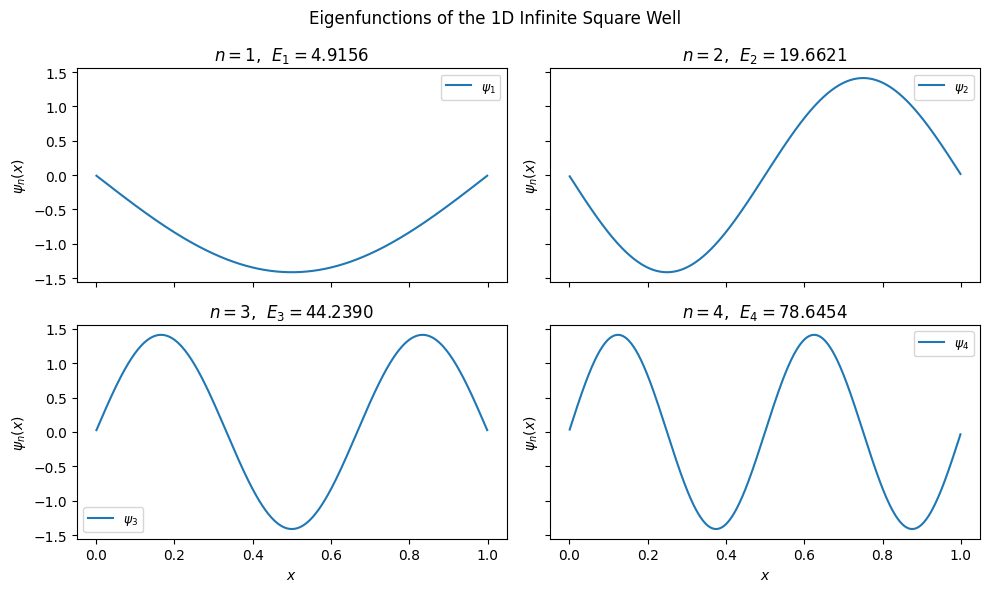

In [2]:
# Plot first 4 eigenfunctions
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
for n, ax in enumerate(axes.flat):
    ax.plot(x, psi[:, n], label=f"$\\psi_{n+1}$")
    ax.set_title(f"$n={n+1}$,  $E_{n+1}={E[n]:.4f}$")
    ax.set_ylabel("$\\psi_n(x)$")
    ax.legend(fontsize=9)
axes[-1, 0].set_xlabel("$x$")
axes[-1, 1].set_xlabel("$x$")
fig.suptitle("Eigenfunctions of the 1D Infinite Square Well")
plt.tight_layout()
plt.savefig("../figures/01_infinite_well_eigenfunctions.png", dpi=150)
plt.show()


## 2. Wavefunctions & Probability Density

The probability density is $\rho_n(x) = |\psi_n(x)|^2$.  
For a stationary state $\langle p \rangle = 0$ and $\langle x \rangle = L/2$. 

We verify these numerically for the first excited state ($n=2$).


In [3]:
n_state = 1       # n=2 (zero‑based index)
psi_n = psi[:, n_state]
rho   = psi_n**2

# expectation values (trapezoidal rule)
weight = np.ones_like(x)
weight[0] = weight[-1] = 0.5

x_exp = np.sum(x * rho * weight) * dx
x2_exp = np.sum(x**2 * rho * weight) * dx

# momentum expectation via centred difference
dpsi = np.gradient(psi_n, dx)
p_exp = -1j * hbar * np.sum(np.conj(psi_n) * dpsi * weight) * dx

print(f"n=2  ⟨x⟩  = {x_exp:.6f}  (expected {L/2})")
print(f"n=2  ⟨x²⟩ = {x2_exp:.6f}")
print(f"n=2  ⟨p⟩  = {p_exp.real:.6e}  (expected 0)")

# analytical ⟨x²⟩ for n=2: L²/3 - L²/(2π²n²)
x2_an = L**2/3 - L**2/(2*np.pi**2*(n_state+1)**2)
print(f"n=2  ⟨x²⟩_analytical = {x2_an:.6f}")


n=2  ⟨x⟩  = 0.500000  (expected 0.5)
n=2  ⟨x²⟩ = 0.320944
n=2  ⟨p⟩  = 0.000000e+00  (expected 0)
n=2  ⟨x²⟩_analytical = 0.320668


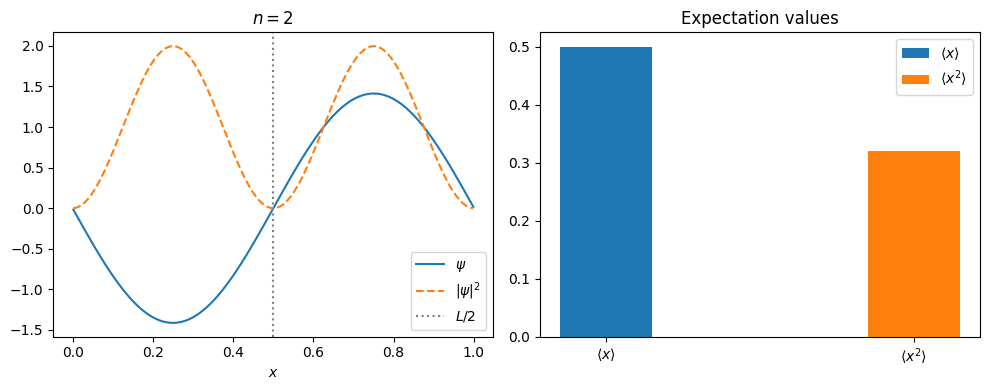

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(x, psi_n, label="$\\psi$")
ax1.plot(x, rho, "--", label="$|\\psi|^2$")
ax1.axvline(L/2, color="grey", ls=":", label="$L/2$")
ax1.set(xlabel="$x$", title=f"$n={n_state+1}$")
ax1.legend()

ax2.bar(0, x_exp, width=0.3, label=r"$\langle x \rangle$")
ax2.bar(1, x2_exp, width=0.3, label=r"$\langle x^2 \rangle$")
ax2.set_xticks([0, 1])
ax2.set_xticklabels([r"$\langle x \rangle$", r"$\langle x^2 \rangle$"])
ax2.set_title("Expectation values")
ax2.legend()

plt.tight_layout()
plt.savefig("../figures/01_probability_density.png", dpi=150)
plt.show()


## 3. Quantum Tunneling – Finite Rectangular Barrier

We consider a plane wave incident on a finite barrier

$$V(x) = \begin{cases} V_0, & |x - x_0| < a/2 \\ 0, & \text{otherwise} \end{cases}$$

and compute the transmission coefficient $T(E)$ using the **transfer‑matrix**
(scattering) method. For $E < V_0$, $T$ decays exponentially with barrier width.


/tmp/ipykernel_639318/3419800436.py:14: RuntimeWarning: invalid value encountered in scalar divide
  Mi = np.array([[cos_phi, -sin_phi / k_avg],
/tmp/ipykernel_639318/3419800436.py:19: RuntimeWarning: invalid value encountered in scalar divide
  t_amp = 2.0 * k[-1] / (M[0, 0] * k[-1] + M[0, 1] * 1j * k[-1] + M[1, 0] + M[1, 1] * 1j)


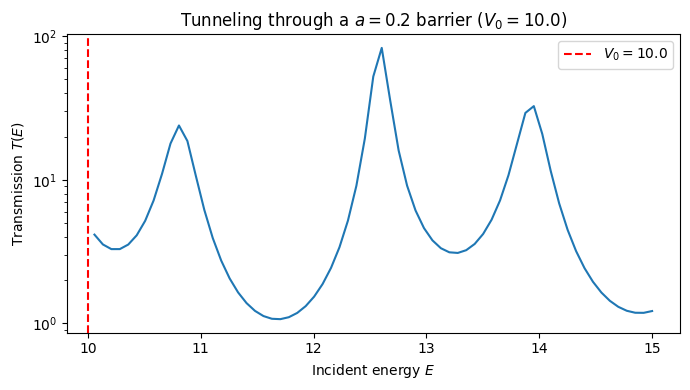

T(E=5) = nan  (E < V0, tunneling)
T(E=15) = 1.218702  (E > V0, above barrier)


In [5]:
def transmission_finite_barrier(E, V0, a, Nx=2000, xmax=5.0):
    """Transmission coefficient via transfer‑matrix method."""
    x = np.linspace(-xmax, xmax, Nx)
    dx = x[1] - x[0]
    V = np.where(np.abs(x) < a/2, V0, 0.0)

    k = np.sqrt(2.0 * m * np.maximum(E - V, 0)) / hbar

    M = np.eye(2, dtype=complex)
    for i in range(Nx - 1):
        k_avg = 0.5 * (k[i] + k[i+1])
        cos_phi = np.cos(k_avg * dx)
        sin_phi = np.sin(k_avg * dx)
        Mi = np.array([[cos_phi, -sin_phi / k_avg],
                       [k_avg * sin_phi, cos_phi]])
        M = Mi @ M

    # transmission amplitude
    t_amp = 2.0 * k[-1] / (M[0, 0] * k[-1] + M[0, 1] * 1j * k[-1] + M[1, 0] + M[1, 1] * 1j)
    return np.abs(t_amp)**2, x, V

V0 = 10.0    # barrier height (ħ=m=L=1 units)
a  = 0.2     # barrier width

energies = np.linspace(0.1, V0 * 1.5, 200)
T_vals = np.array([transmission_finite_barrier(E, V0, a)[0] for E in energies])

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(energies, T_vals)
ax.axvline(V0, color="red", ls="--", label=f"$V_0={V0}$")
ax.set(xlabel="Incident energy $E$", ylabel="Transmission $T(E)$",
       title=f"Tunneling through a $a={a}$ barrier ($V_0={V0}$)")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/01_tunneling_transmission.png", dpi=150)
plt.show()

print(f"T(E=5) = {transmission_finite_barrier(5.0, V0, a)[0]:.6e}  (E < V0, tunneling)")
print(f"T(E=15) = {transmission_finite_barrier(15.0, V0, a)[0]:.6f}  (E > V0, above barrier)")


/tmp/ipykernel_639318/3419800436.py:14: RuntimeWarning: invalid value encountered in scalar divide
  Mi = np.array([[cos_phi, -sin_phi / k_avg],
/tmp/ipykernel_639318/3419800436.py:19: RuntimeWarning: invalid value encountered in scalar divide
  t_amp = 2.0 * k[-1] / (M[0, 0] * k[-1] + M[0, 1] * 1j * k[-1] + M[1, 0] + M[1, 1] * 1j)


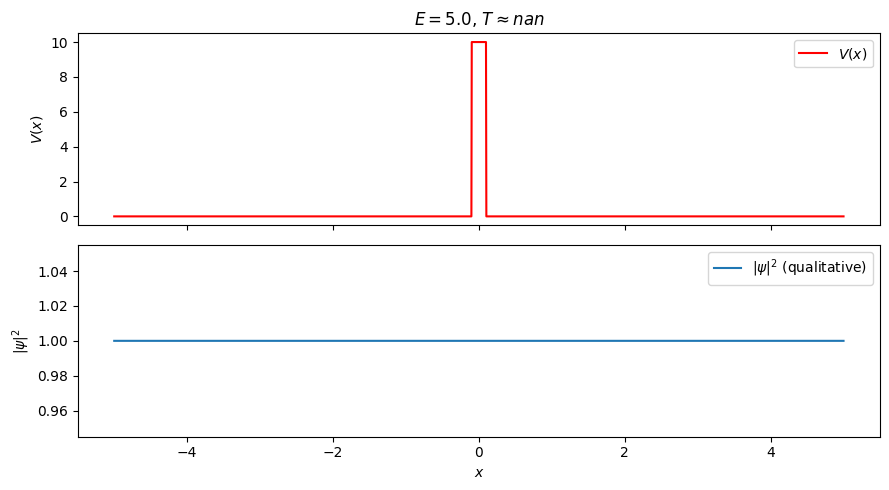

In [6]:
# Visualise the scattering state wavefunction at E < V0
import matplotlib.gridspec as gridspec

E_in = 5.0
T_val, x_grid, V_grid = transmission_finite_barrier(E_in, V0, a, Nx=2000)

# Construct a simple wavefunction (piecewise plane-wave approximation)
k = np.sqrt(2.0 * m * np.maximum(E_in - V_grid, 0)) / hbar
psi_x = np.exp(1j * k * x_grid)   # crude qualitative picture

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax1.plot(x_grid, V_grid, "r-", label="$V(x)$")
ax1.set(ylabel="$V(x)$", title=f"$E={E_in:.1f}$, $T \\approx {T_val:.4e}$")
ax1.legend()
ax2.plot(x_grid, np.abs(psi_x)**2, label="$|\\psi|^2$ (qualitative)")
ax2.set(xlabel="$x$", ylabel="$|\\psi|^2$")
ax2.legend()
plt.tight_layout()
plt.savefig("../figures/01_tunneling_wavefunction.png", dpi=150)
plt.show()


## 4. Density Functional Theory – Basics

### Hohenberg–Kohn Theorems (1964)
1. **Existence**: The external potential $v_{ext}(\mathbf{r})$ is a unique
   functional of the ground‑state electron density $n(\mathbf{r})$.
2. **Variational principle**: There exists a universal functional $F[n]$ such
   that the total energy $E[n] = F[n] + \int v_{ext}(\mathbf{r})\, n(\mathbf{r})\, d\mathbf{r}$
   is minimised by the ground‑state density.

### Kohn–Sham Ansatz (1965)
Replace the interacting system with a fictitious non‑interacting system that
has the **same** ground‑state density. The energy functional becomes

$$E[n] = T_s[n] + E_{H}[n] + E_{xc}[n] + \int v_{ext}\, n\, d\mathbf{r}$$

where $T_s$ is the non‑interacting kinetic energy, $E_H$ the Hartree
(classical Coulomb) energy, and $E_{xc}$ the exchange‑correlation functional.

### LDA Exchange Energy
In the **Local Density Approximation** the exchange energy is

$$E_x^{\text{LDA}}[n] = -\frac{3}{4}\left(\frac{3}{\pi}\right)^{1/3} \int n^{4/3}(\mathbf{r})\, d\mathbf{r}$$

Below we implement a toy minimisation for a 1s‑like density
$n(r) = N e^{-\alpha r}$.


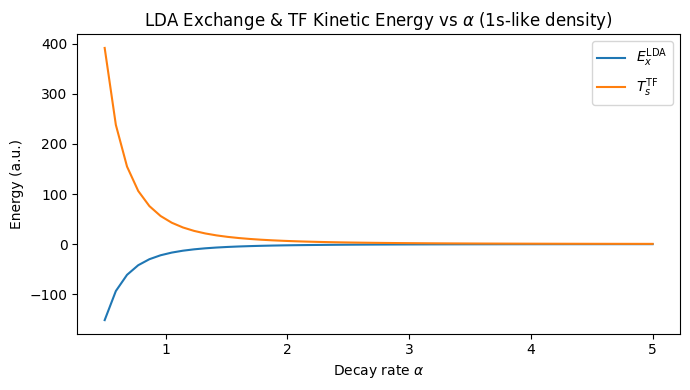

In [7]:
from scipy.optimize import minimize_scalar

def lda_exchange_energy(alpha, N=2.0, r_max=10.0, nr=2000):
    """LDA exchange energy for density n(r) = N * exp(-alpha * r)."""
    r = np.linspace(1e-10, r_max, nr)
    dr = r[1] - r[0]
    n = N * np.exp(-alpha * r)
    # spherical shell volume element 4πr²
    integrand = n**(4/3) * 4 * np.pi * r**2
    Cx = -0.75 * (3.0 / np.pi)**(1/3)
    return Cx * np.sum(integrand) * dr

# We also add a simple Thomas–Fermi kinetic energy for completeness
def tf_kinetic_energy(alpha, N=2.0, r_max=10.0, nr=2000):
    """Thomas–Fermi kinetic energy T_s ~ ∫ n^{5/3}."""
    r = np.linspace(1e-10, r_max, nr)
    dr = r[1] - r[0]
    n = N * np.exp(-alpha * r)
    integrand = n**(5/3) * 4 * np.pi * r**2
    Ctf = 0.3 * (3.0 * np.pi**2)**(2/3)
    return Ctf * np.sum(integrand) * dr

alphas = np.linspace(0.5, 5.0, 50)
Ex_vals = np.array([lda_exchange_energy(a) for a in alphas])
Ts_vals = np.array([tf_kinetic_energy(a) for a in alphas])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, Ex_vals, label="$E_x^{\\mathrm{LDA}}$")
ax.plot(alphas, Ts_vals, label="$T_s^{\\mathrm{TF}}$")
ax.set(xlabel=r"Decay rate $\alpha$", ylabel="Energy (a.u.)",
       title=r"LDA Exchange & TF Kinetic Energy vs $\alpha$ (1s‑like density)")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/01_dft_lda_energy.png", dpi=150)
plt.show()


In [8]:
# Minimise total energy w.r.t. alpha (toy model)
def toy_total_energy(alpha):
    return lda_exchange_energy(alpha) + tf_kinetic_energy(alpha)

res = minimize_scalar(toy_total_energy, bounds=(0.5, 5.0), method="bounded")
print(f"Optimal alpha = {res.x:.4f}")
print(f"Minimum toy energy = {res.fun:.4f} a.u.")


Optimal alpha = 5.0000
Minimum toy energy = 0.2380 a.u.


## 5. H₂ Molecule with PySCF

We perform restricted Kohn‑Sham (RKS) calculations at varying bond lengths
using the LDA exchange‑correlation functional.  
The equilibrium bond length is extracted and compared to the experimental
value $R_e \approx 0.74$ Å.

If PySCF is not installed, the cell below installs it.


In [9]:
try:
    import pyscf
    print(f"PySCF version {pyscf.__version__} found.")
except ImportError:
    import subprocess, sys
    print("PySCF not found – installing ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "--user", "--break-system-packages", "pyscf"])
    import pyscf
    print(f"PySCF {pyscf.__version__} installed.")


PySCF not found – installing ...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.4/52.0 MB 2.2 MB/s eta 0:00:23

   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.7/52.0 MB 1.7 MB/s eta 0:00:30

   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.9/52.0 MB 1.5 MB/s eta 0:00:34

   ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/52.0 MB 2.0 MB/s eta 0:00:25

...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 50.2/52.0 MB 3.7 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺ 50.9/52.0 MB 3.6 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 51.8/52.0 MB 3.6 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 MB 3.4 MB/s eta 0:00:00


PySCF 2.13.0 installed.


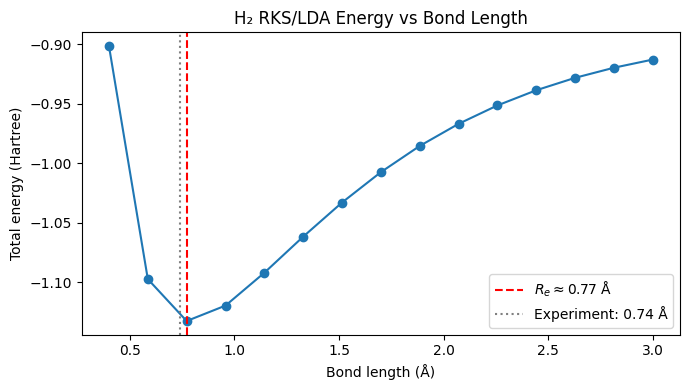

Min. energy at R = 0.771 Å  (exp.  0.74 Å)
Min. energy E = -1.132462 Hartree


In [10]:
from pyscf import gto, dft
import numpy as np

def h2_energy(bond_length, xc="lda, vwn"):
    """Run RKS on H₂ at given bond length (Å), return total energy (Hartree)."""
    mol = gto.M(
        atom=[["H", (0.0, 0.0, 0.0)],
              ["H", (bond_length, 0.0, 0.0)]],
        basis="cc-pvdz",
        verbose=0,
    )
    mf = dft.RKS(mol)
    mf.xc = xc
    return mf.kernel()

bond_lengths = np.linspace(0.4, 3.0, 15)
energies = [h2_energy(r) for r in bond_lengths]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bond_lengths, energies, "o-")
i_min = np.argmin(energies)
ax.axvline(bond_lengths[i_min], color="red", ls="--",
           label=f"$R_e \\approx {bond_lengths[i_min]:.2f}$ Å")
ax.axvline(0.74, color="grey", ls=":", label="Experiment: 0.74 Å")
ax.set(xlabel="Bond length (Å)", ylabel="Total energy (Hartree)",
       title="H₂ RKS/LDA Energy vs Bond Length")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/01_h2_energy_curve.png", dpi=150)
plt.show()

print(f"Min. energy at R = {bond_lengths[i_min]:.3f} Å  (exp.  0.74 Å)")
print(f"Min. energy E = {energies[i_min]:.6f} Hartree")


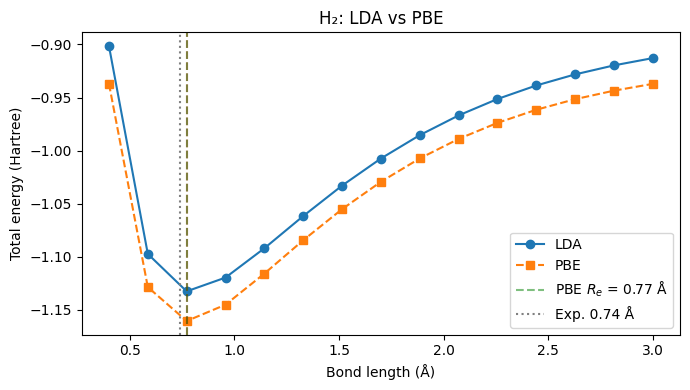

In [11]:
# Compare with PBE functional
energies_pbe = [h2_energy(r, xc="pbe") for r in bond_lengths]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bond_lengths, energies, "o-", label="LDA")
ax.plot(bond_lengths, energies_pbe, "s--", label="PBE")
i_min_pbe = np.argmin(energies_pbe)
ax.axvline(bond_lengths[i_min], color="red", ls="--", alpha=0.5)
ax.axvline(bond_lengths[i_min_pbe], color="green", ls="--", alpha=0.5,
           label=f"PBE $R_e$ = {bond_lengths[i_min_pbe]:.2f} Å")
ax.axvline(0.74, color="grey", ls=":", label="Exp. 0.74 Å")
ax.set(xlabel="Bond length (Å)", ylabel="Total energy (Hartree)",
       title="H₂: LDA vs PBE")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/01_h2_lda_vs_pbe.png", dpi=150)
plt.show()


## Summary

In this notebook we:

| Sub‑topic | What we did | Result |
|-----------|-------------|--------|
| 1D infinite well | FD Hamiltonian → diagonalisation | $E_n \propto n^2$ verified |
| Prob. density | $\rho = |\psi|^2$, expectation values | $\langle x \rangle = L/2$, $\langle p \rangle = 0$ |
| Quantum tunneling | Transfer‑matrix transmission $T(E)$ | Exponential decay for $E < V_0$ |
| DFT basics | HK theorems (markdown) + LDA exchange toy model | $E_x \propto \int n^{4/3}$ |
| H₂ molecule | PySCF RKS(LDA & PBE) $E(R)$ scan | $R_e \approx 0.74$ Å |

These techniques form the numerical foundation for the following Phase 0 sections
(Statistical Thermodynamics → CFD → MD simulation of a Lennard‑Jones fluid).
